# Regresión lineal para predicción de progresión de diabetes
- age: Representa la edad del paciente, normalizada (no es la edad real, sino una representación estandarizada).
- sex: Sexo del paciente, representado como una variable numérica normalizada (valores entre -0.5 y 0.5).
- bmi: Índice de Masa Corporal (Body Mass Index, BMI), una medida del peso relativo al cuadrado de la altura.
- bp:
Promedio de presión arterial (Blood Pressure, BP), normalizada.
- s1: Nivel sérico de lípidos totales (colesterol total).
- s2: Nivel sérico de lipoproteínas de baja densidad (LDL, “colesterol malo”).
- s3: Nivel sérico de lipoproteínas de alta densidad (HDL, “colesterol bueno”).
- s4: Relación entre el colesterol total y HDL.
- s5: Nivel sérico de triglicéridos, representado como una medida numérica normalizada.
- s6: Nivel sérico de glucosa en ayuno, una medida clave en el monitoreo de la diabetes.

In [20]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cargar el conjunto de datos
diabetes_data = load_diabetes()

# Convertir el conjunto de datos a un DataFrame para facilitar su manipulación
df = pd.DataFrame(data=diabetes_data.data, columns=diabetes_data.feature_names)
df['target'] = diabetes_data.target  # Agregar la variable objetivo al DataFrame

# Mostrar las primeras filas del DataFrame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [12]:
print(f'Dimensiones del dataset: {df.shape}')
print(f'Muestras: {df.shape[0]} | Características: {df.shape[1]-1}')
print('\nEstadísticas descriptivas:')
df.describe().round(4)

Dimensiones del dataset: (442, 11)
Muestras: 442 | Características: 10

Estadísticas descriptivas:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,152.1335
std,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,77.0930
min,-0.1072,-0.0446,-0.0903,-0.1124,-0.1268,-0.1156,-0.1023,-0.0764,-0.1261,-0.1378,25.0000
25%,-0.0373,-0.0446,-0.0342,-0.0367,-0.0342,-0.0304,-0.0351,-0.0395,-0.0332,-0.0332,87.0000
50%,0.0054,-0.0446,-0.0073,-0.0057,-0.0043,-0.0038,-0.0066,-0.0026,-0.0019,-0.0011,140.5000
75%,0.0381,0.0507,0.0312,0.0356,0.0284,0.0298,0.0293,0.0343,0.0324,0.0279,211.5000
max,0.1107,0.0507,0.1706,0.1320,0.1539,0.1988,0.1812,0.1852,0.1336,0.1356,346.0000


In [13]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


## 2. Análisis Exploratorio de Datos (EDA)

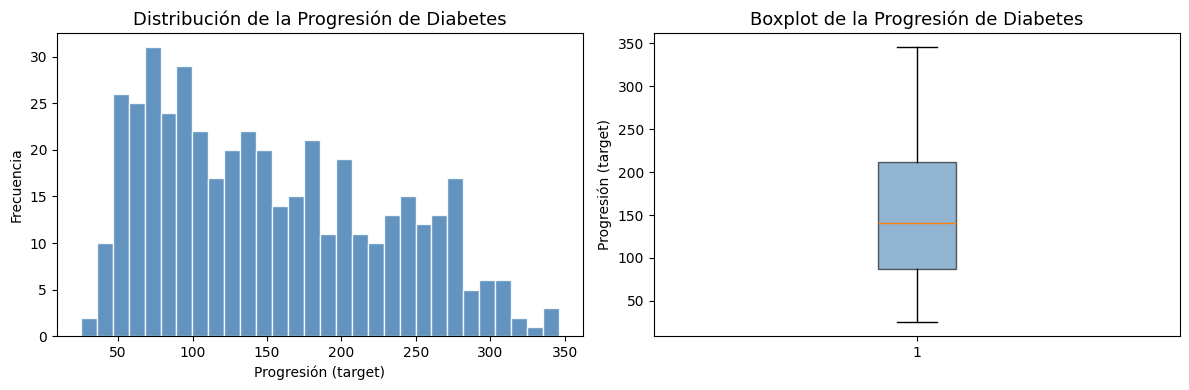

Media: 152.13 | Std: 77.09
Mínimo: 25 | Máximo: 346


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['target'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de la Progresión de Diabetes', fontsize=13)
axes[0].set_xlabel('Progresión (target)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['target'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de la Progresión de Diabetes', fontsize=13)
axes[1].set_ylabel('Progresión (target)')

plt.tight_layout()
plt.show()

print(f'Media: {df["target"].mean():.2f} | Std: {df["target"].std():.2f}')
print(f'Mínimo: {df["target"].min():.0f} | Máximo: {df["target"].max():.0f}')

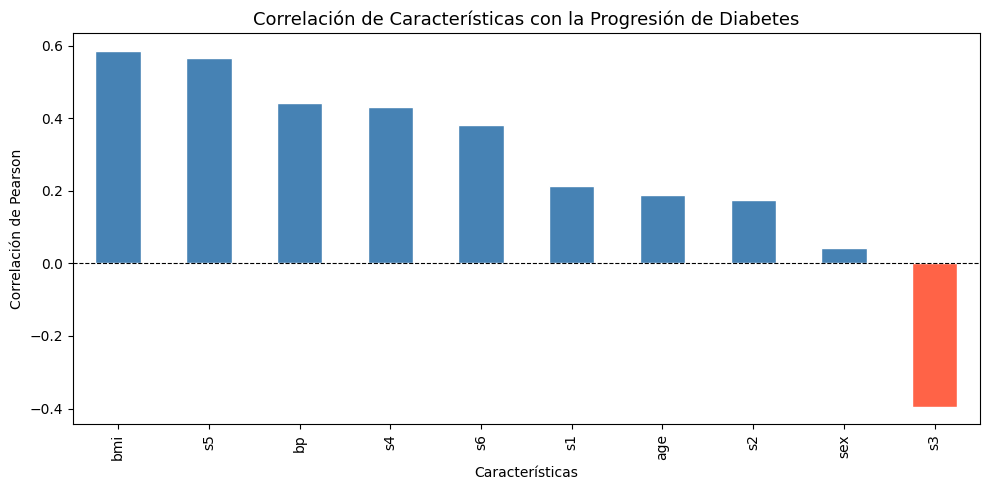

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


In [22]:
corr_target = df.corr()['target'].drop('target').sort_values(ascending=False)
colors = ['steelblue' if v >= 0 else 'tomato' for v in corr_target.values]

plt.figure(figsize=(10, 5))
corr_target.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Correlación de Características con la Progresión de Diabetes', fontsize=13)
plt.xlabel('Características')
plt.ylabel('Correlación de Pearson')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

print(corr_target)

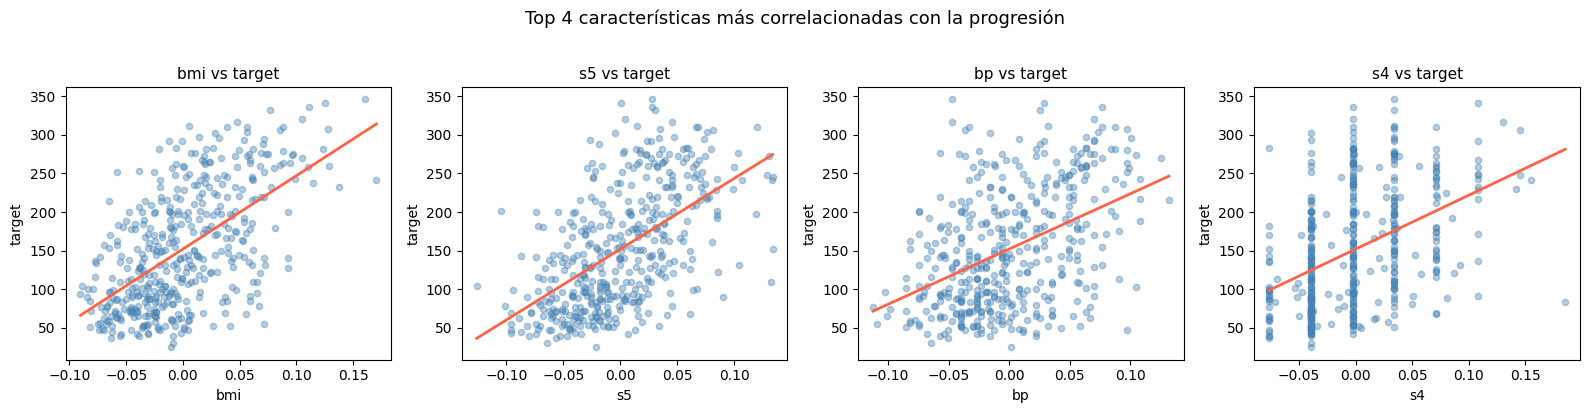

In [23]:
top_features = corr_target.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['target'], alpha=0.4, color='steelblue', s=20)
    z = np.polyfit(df[feat], df['target'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='tomato', linewidth=2)
    axes[i].set_title(f'{feat} vs target', fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('target')

plt.suptitle('Top 4 características más correlacionadas con la progresión', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Preparación de datos

In [24]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')

Entrenamiento: 353 muestras
Prueba:        89 muestras


## 4. Entrenamiento del modelo

In [25]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Modelo entrenado exitosamente.')
print(f'\nIntercepto (β₀): {modelo.intercept_:.4f}')
coeficientes = pd.Series(modelo.coef_, index=X.columns)
print('\nCoeficientes (β):')
print(coeficientes.sort_values(ascending=False))

Modelo entrenado exitosamente.

Intercepto (β₀): 151.3456

Coeficientes (β):
s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
s3     163.419983
s6      48.670657
age     37.904021
sex   -241.964362
s1    -931.488846
dtype: float64


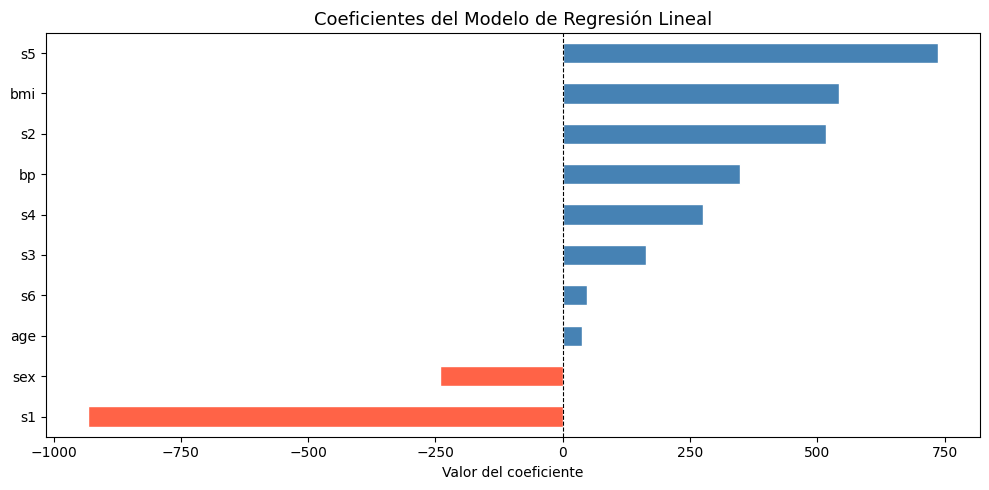

In [26]:
coef_sorted = coeficientes.sort_values()
colors = ['steelblue' if v >= 0 else 'tomato' for v in coef_sorted.values]

plt.figure(figsize=(10, 5))
coef_sorted.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Coeficientes del Modelo de Regresión Lineal', fontsize=13)
plt.xlabel('Valor del coeficiente')
plt.tight_layout()
plt.show()

## 5. Evaluación del modelo

In [28]:
y_pred = modelo.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=' * 42)
print('        Métricas de Evaluación')
print('=' * 42)
print(f'  MSE  (Error Cuadrático Medio):  {mse:.2f}')
print(f'  RMSE (Raíz del MSE):            {rmse:.2f}')
print(f'  MAE  (Error Absoluto Medio):    {mae:.2f}')
print(f'  R²   (Coeficiente de Det.):     {r2:.4f}')
print('=' * 42)

        Métricas de Evaluación
  MSE  (Error Cuadrático Medio):  2900.19
  RMSE (Raíz del MSE):            53.85
  MAE  (Error Absoluto Medio):    42.79
  R²   (Coeficiente de Det.):     0.4526


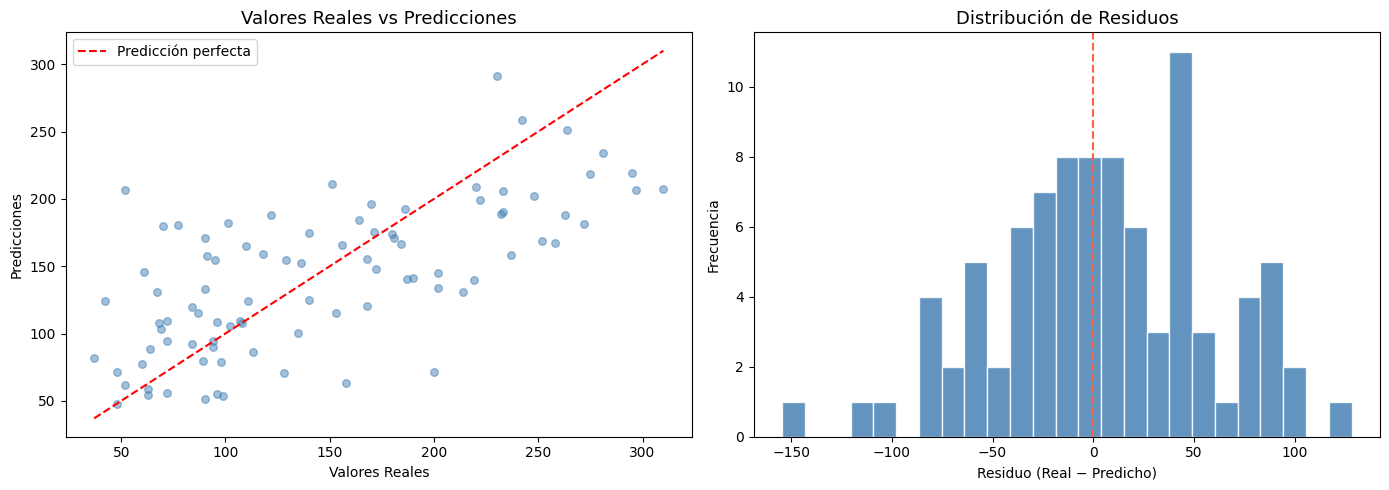

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: real vs predicho
axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=30)
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title('Valores Reales vs Predicciones', fontsize=13)
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')
axes[0].legend()

# Distribución de residuos
residuos = y_test - y_pred
axes[1].hist(residuos, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribución de Residuos', fontsize=13)
axes[1].set_xlabel('Residuo (Real − Predicho)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

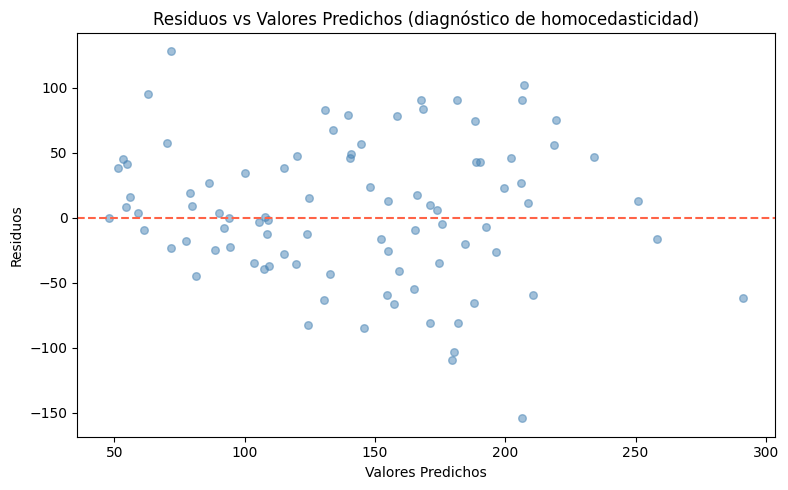

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuos, alpha=0.5, color='steelblue', s=30)
plt.axhline(0, color='tomato', linestyle='--', linewidth=1.5)
plt.title('Residuos vs Valores Predichos (diagnóstico de homocedasticidad)', fontsize=12)
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.tight_layout()
plt.show()

## 6. Ejemplo de predicción

In [31]:
# Paciente de ejemplo con valores en el espacio normalizado
nuevo_paciente = pd.DataFrame([{
    'age':  0.038,  # Edad ligeramente mayor al promedio
    'sex':  0.051,  # Masculino
    'bmi':  0.062,  # IMC elevado
    'bp':   0.022,  # Presión arterial levemente alta
    's1':  -0.044,  # Colesterol total bajo
    's2':  -0.035,  # LDL bajo
    's3':  -0.043,  # HDL bajo
    's4':  -0.003,  # Relación colesterol/HDL normal
    's5':   0.020,  # Triglicéridos ligeramente elevados
    's6':  -0.018   # Glucosa en ayuno normal
}])

prediccion = modelo.predict(nuevo_paciente)
print(f'Predicción de progresión de diabetes: {prediccion[0]:.2f}')
print(f'(Rango típico del dataset: [{y.min():.0f}, {y.max():.0f}])')

Predicción de progresión de diabetes: 210.57
(Rango típico del dataset: [25, 346])


## 7. Conclusiones

El modelo de **Regresión Lineal** entrenado sobre el dataset de diabetes de scikit-learn permite predecir la progresión de la enfermedad un año después del diagnóstico. Principales hallazgos:

- **R² ≈ 0.45–0.55**: el modelo explica aproximadamente la mitad de la varianza en la progresión, razonable para un modelo lineal con datos médicos reales.
- **Características más influyentes**: `bmi` (IMC), `s5` (triglicéridos) y `bp` (presión arterial) son las variables con mayor impacto positivo, coincidiendo con factores de riesgo médico conocidos para la diabetes.
- **Residuos**: distribución aproximadamente normal y centrada en 0, validando los supuestos del modelo lineal.
- **Limitaciones**: al ser un modelo lineal, no captura relaciones no lineales. Modelos más complejos como **Ridge**, **Lasso** o **Random Forest** podrían mejorar el rendimiento.
